# 실습 3·4 — 이미지 데이터 증강 (2교시)

**학습 목표**
- 과적합과 일반화를 이해하고, 데이터 증강이 왜 필요한지 설명한다.
- `torchvision.transforms`의 핵심 증강 8가지를 직접 적용한다.
- `Compose`로 학습용/검증용 파이프라인을 분리해서 만든다.
- CIFAR-10에 증강을 적용하고 매번 다른 결과가 나오는 것을 확인한다.

**사전 조건**
- 1교시 노트북(`01_image_basics.ipynb`) 완료, `preprocess` 파이프라인 이해
- `sample_images/dog.jpg` 존재


## 셀 [0] — 한글 폰트 + 공통 import

In [1]:
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False

## 셀 [1] — 이미지 로드 + 시각화 보조 함수

In [2]:
from PIL import Image
from torchvision import transforms

img = Image.open("sample_images/dog.jpg").convert("RGB")

def show(images, titles, ncols=4):
    """이미지 리스트를 grid로 시각화하는 보조 함수"""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im); ax.set_title(t); ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

print(f"원본 크기: {img.size}")

원본 크기: (330, 219)


## 셀 [2] — RandomHorizontalFlip (좌우 반전)

`p=1.0`으로 항상 반전하여 시연. 실제 학습에서는 `p=0.5`.

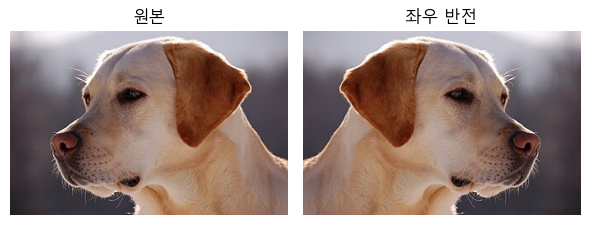

In [3]:
hflip = transforms.RandomHorizontalFlip(p=1.0)
show([img, hflip(img)], ["원본", "좌우 반전"], ncols=2)

## 셀 [3] — RandomRotation (무작위 회전)

같은 변환을 4번 적용해 무작위성을 확인. 모서리 검은 빈 공간이 보입니다.

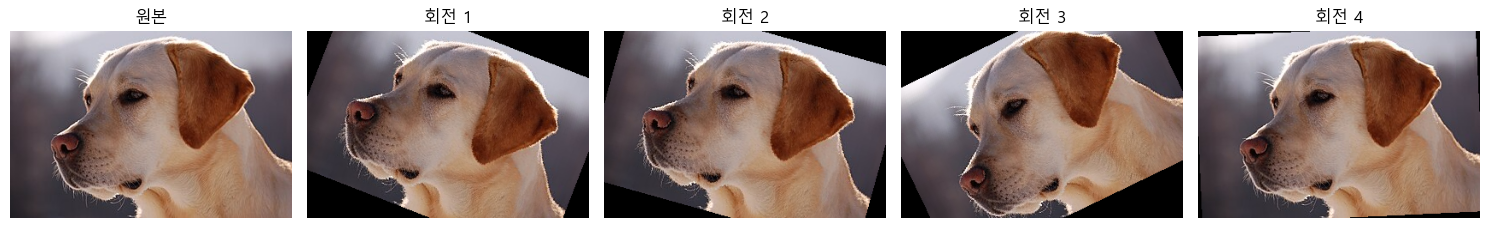

In [4]:
rotate = transforms.RandomRotation(degrees=30)
rotated = [rotate(img) for _ in range(4)]
show([img] + rotated,
     ["원본", "회전 1", "회전 2", "회전 3", "회전 4"], ncols=5)

### 셀 [3-1] — fill / expand 옵션 비교

회전 모서리 빈 공간 처리. `fill=128`(회색), `expand=True`(이미지 자체 확장).

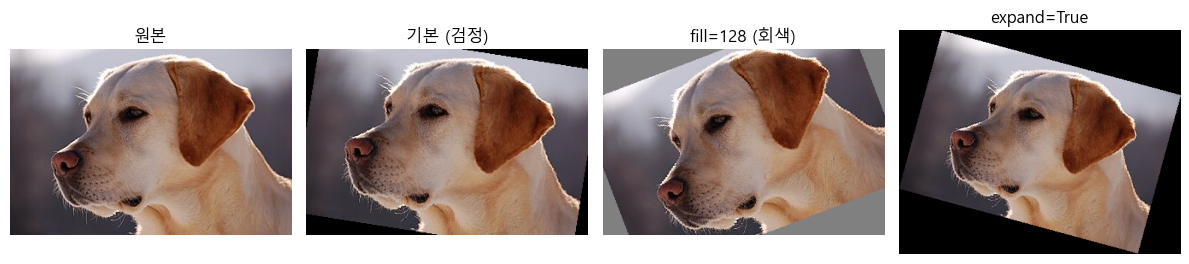

In [5]:
rotate_fill = transforms.RandomRotation(degrees=30, fill=128)
rotate_expand = transforms.RandomRotation(degrees=30, expand=True)
show(
    [img, rotate(img), rotate_fill(img), rotate_expand(img)],
    ["원본", "기본 (검정)", "fill=128 (회색)", "expand=True"],
    ncols=4,
)

## 셀 [4] — RandomResizedCrop (자르기 + 확대)

원본의 50~100% 영역을 무작위로 잘라 224×224로 리사이즈.

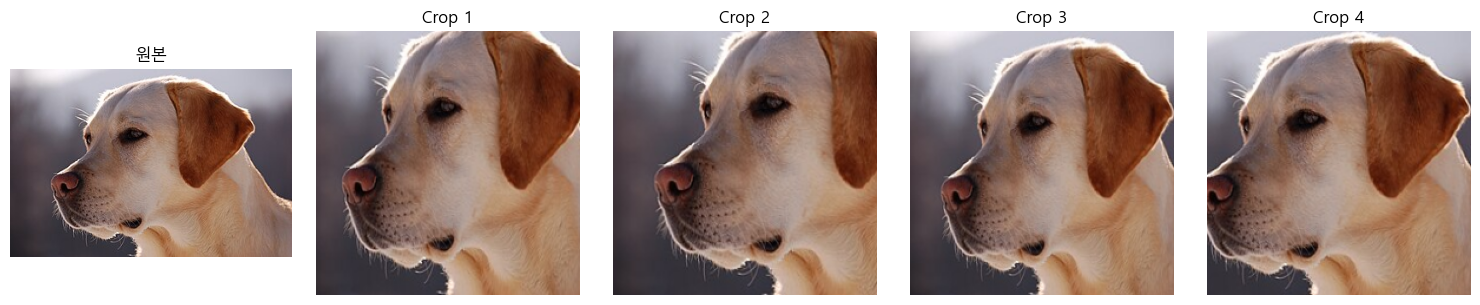

In [6]:
crop = transforms.RandomResizedCrop(
    size=224,
    scale=(0.5, 1.0),
    ratio=(0.75, 1.33),
)
cropped = [crop(img) for _ in range(4)]
show([img] + cropped,
     ["원본", "Crop 1", "Crop 2", "Crop 3", "Crop 4"], ncols=5)

### 셀 [4-1] — scale을 극단적으로 작게 했을 때 (Aliasing 확인)

`scale=(0.08, 0.1)`로 원본의 ~10%만 추출 → 224×224로 강제 확대. 정보량은 그대로인데 픽셀만 늘어남.

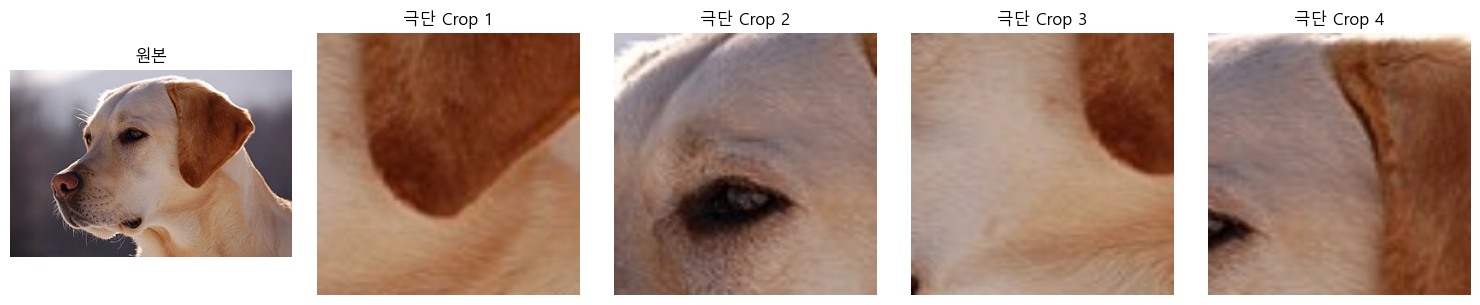

In [7]:
crop_extreme = transforms.RandomResizedCrop(size=224, scale=(0.08, 0.1))
extreme = [crop_extreme(img) for _ in range(4)]
show([img] + extreme,
     ["원본", "극단 Crop 1", "극단 Crop 2", "극단 Crop 3", "극단 Crop 4"], ncols=5)

## 셀 [5] — ColorJitter (밝기·대비·채도·색조)

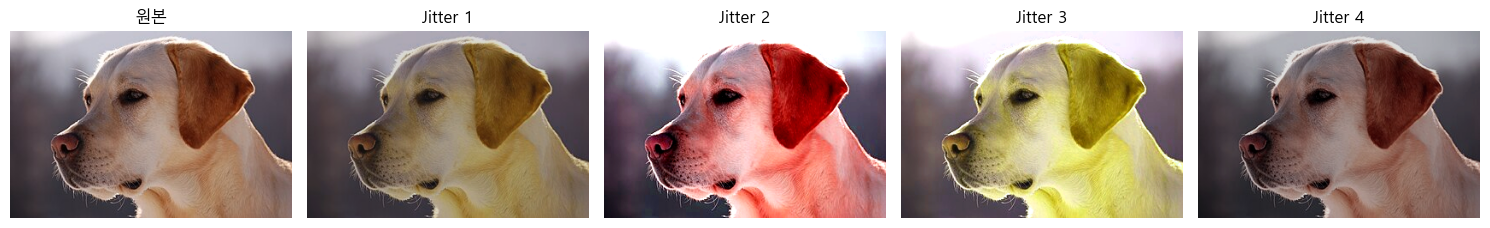

In [8]:
jitter = transforms.ColorJitter(
    brightness=0.3,
    contrast=0.3,
    saturation=0.3,
    hue=0.1,
)
jittered = [jitter(img) for _ in range(4)]
show([img] + jittered,
     ["원본", "Jitter 1", "Jitter 2", "Jitter 3", "Jitter 4"], ncols=5)

## 셀 [6] — RandomGrayscale (흑백화)

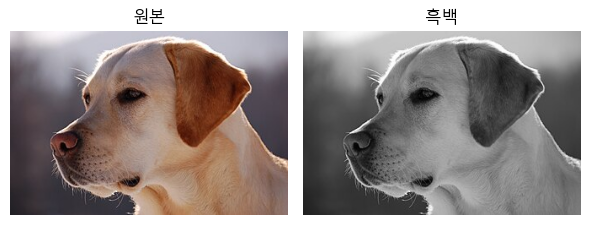

In [9]:
gray = transforms.RandomGrayscale(p=1.0)
show([img, gray(img)], ["원본", "흑백"], ncols=2)

## 셀 [7] — GaussianBlur (가우시안 흐림)

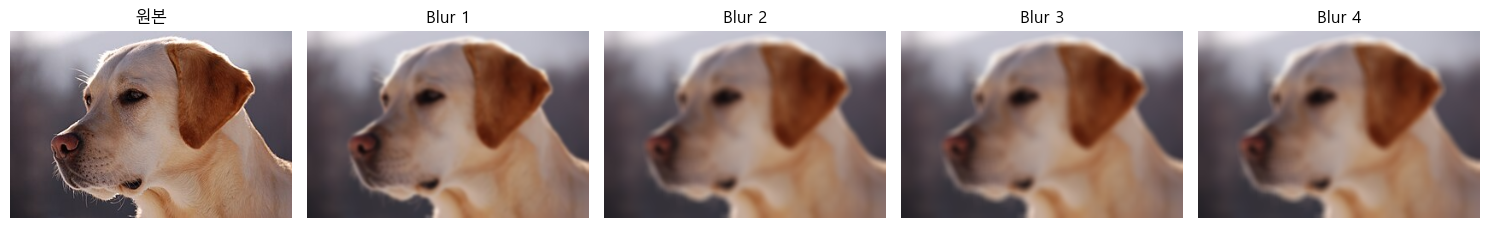

In [10]:
blur = transforms.GaussianBlur(kernel_size=11, sigma=(0.1, 5.0))
blurred = [blur(img) for _ in range(4)]
show([img] + blurred,
     ["원본", "Blur 1", "Blur 2", "Blur 3", "Blur 4"], ncols=5)

## 셀 [8] — 학습용 / 검증용 파이프라인 분리 ★

**학습용**: 증강 ON / **검증용**: 결정적 전처리만.

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("train_transform / val_transform 정의 완료")

train_transform / val_transform 정의 완료


## 셀 [9] — 같은 사진에 12번 적용 (시각화용, Normalize 제외)

원본 1장 → 12장이 모두 다른 사진처럼 보임.

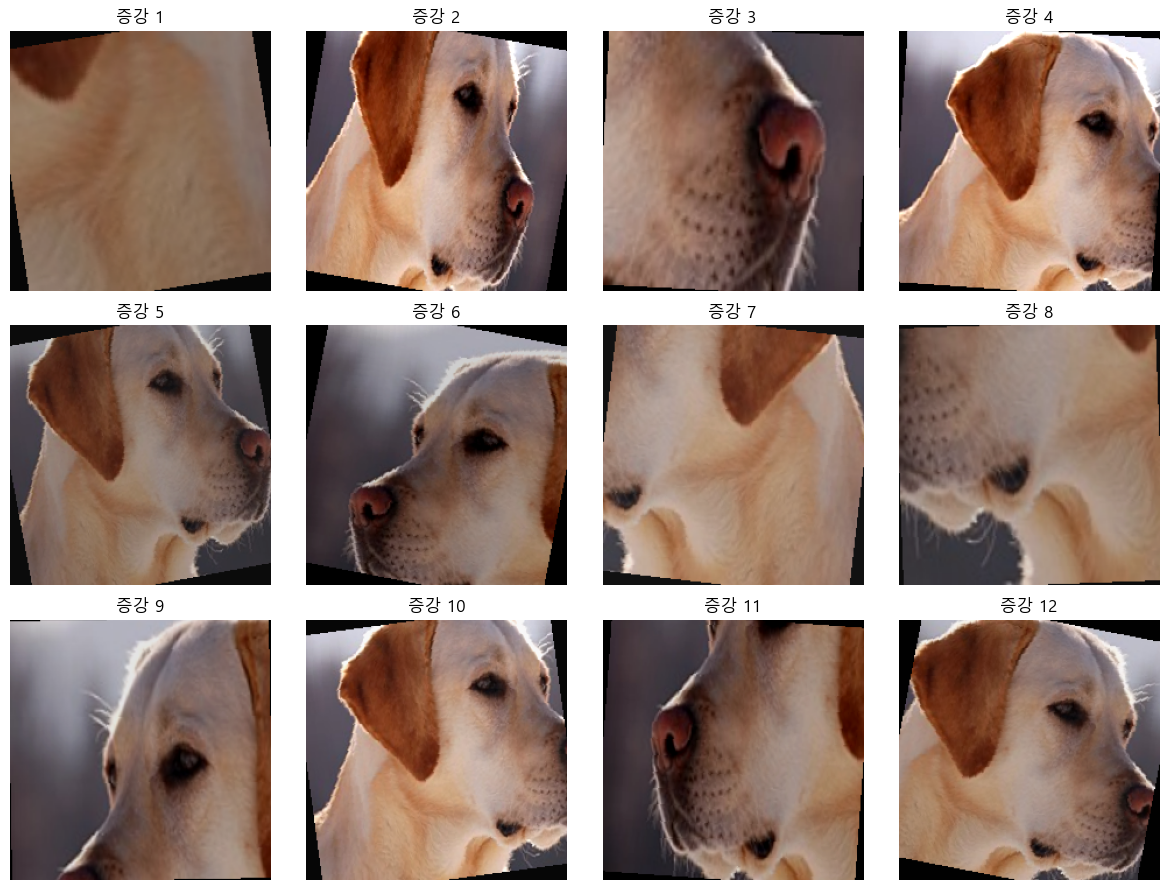

In [12]:
viz_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

augmented = [viz_transform(img) for _ in range(12)]
show(augmented, [f"증강 {i+1}" for i in range(12)], ncols=4)

## 셀 [10] — CIFAR-10에 증강 적용

`with_transform`은 꺼낼 때마다 함수를 실행 → 매번 다른 결과.

In [13]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

def transform_train(batch):
    batch["pixel_values"] = [train_transform(img.convert("RGB")) for img in batch["img"]]
    return batch

def transform_val(batch):
    batch["pixel_values"] = [val_transform(img.convert("RGB")) for img in batch["img"]]
    return batch

ds_train = ds["train"].with_transform(transform_train)
ds_test = ds["test"].with_transform(transform_val)

first1 = ds_train[0]["pixel_values"]
first2 = ds_train[0]["pixel_values"]
print(f"같은 인덱스 두 번 호출 — 같은 결과? {(first1 == first2).all().item()}")

C:\Users\6-112\Desktop\빅데이터분석프로그래밍\2026_bigdata_QB\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


같은 인덱스 두 번 호출 — 같은 결과? False


## 셀 [11] — CIFAR-10 강아지 한 장을 8번 변형해 보기 (denormalize 시각화)

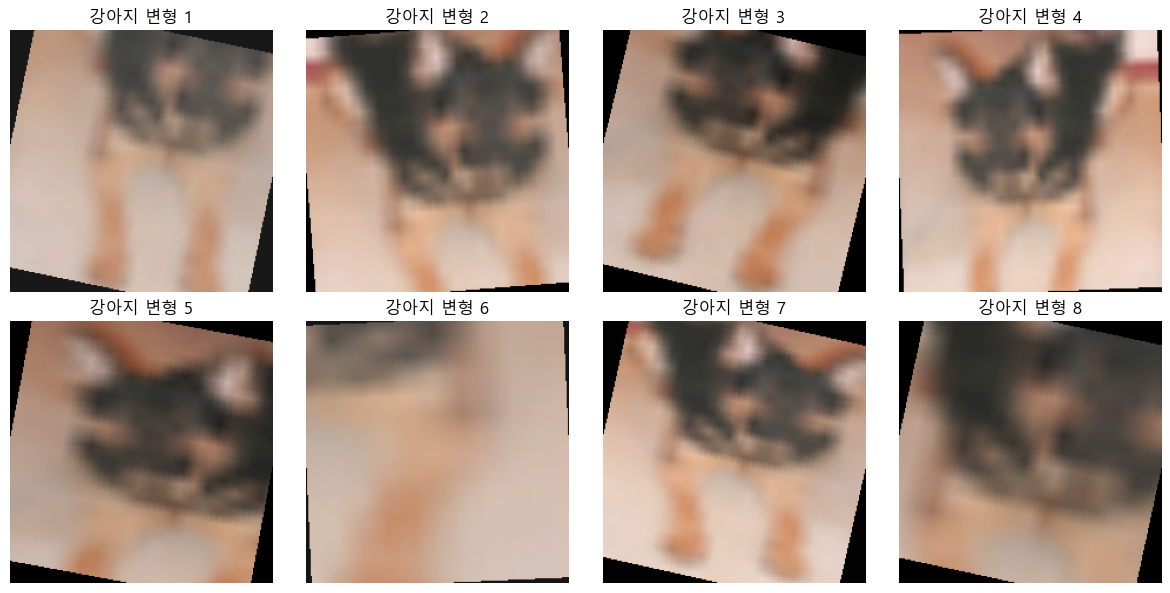

In [14]:
import torch

def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

label_names = ds["train"].features["label"].names
dog_idx = next(i for i in range(100) if ds["train"][i]["label"] == 5)

variations = [denormalize(ds_train[dog_idx]["pixel_values"]).permute(1, 2, 0)
              for _ in range(8)]
show(variations, [f"강아지 변형 {i+1}" for i in range(8)], ncols=4)

## 셀 [12] — 학생 자율 실습: 내가 만든 증강 조합 ★

아래 파라미터를 자유롭게 바꿔 결과를 비교해보세요.
여유가 있다면 `img` 대신 본인 휴대폰 사진(`sample_images/my_phone.jpg`)을 넣어보세요.

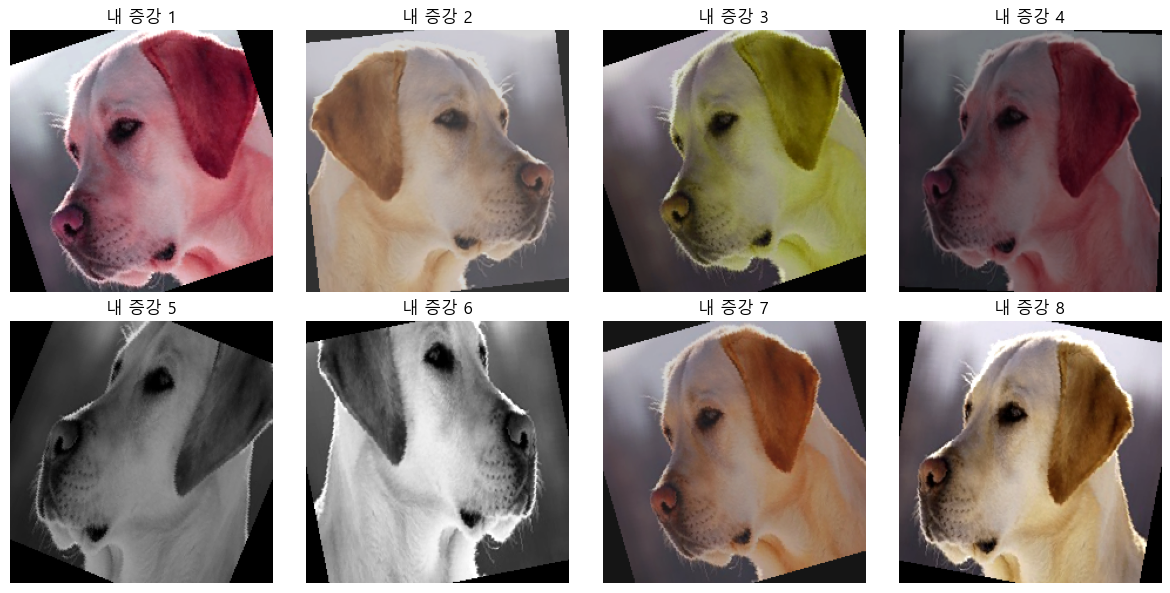

In [15]:
my_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),     # ← scale 범위 바꾸기
    transforms.RandomHorizontalFlip(p=0.5),                   # ← 확률 바꾸기
    transforms.RandomRotation(degrees=30),                    # ← 각도 바꾸기
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.4, hue=0.1),          # ← 강도 바꾸기
    transforms.RandomGrayscale(p=0.2),                        # ← 흑백 확률 바꾸기
    # transforms.GaussianBlur(kernel_size=5),                  # ← 주석 풀어보기
])

mine = [my_transform(img) for _ in range(8)]
show(mine, [f"내 증강 {i+1}" for i in range(8)], ncols=4)

## 셀 [13] — 증강 퀴즈 (어떤 변환이 적용됐을까?)

라벨을 가린 채로 보여주고, 학생들이 어떤 증강인지 맞히기.

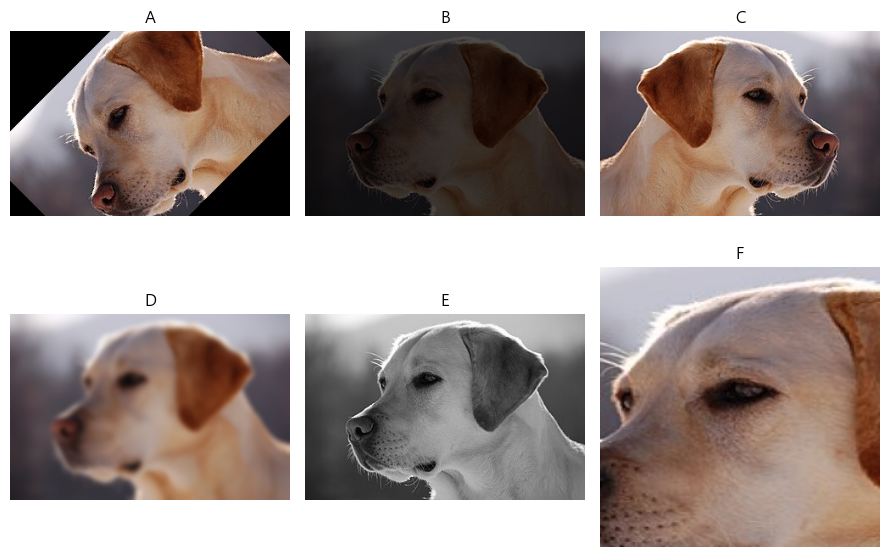

정답: {'A': 'RandomRotation', 'B': 'ColorJitter', 'C': 'RandomHorizontalFlip', 'D': 'GaussianBlur', 'E': 'RandomGrayscale', 'F': 'RandomResizedCrop'}


In [16]:
quiz_transforms = {
    "A": transforms.RandomRotation(degrees=(45, 45)),
    "B": transforms.ColorJitter(brightness=(0.3, 0.3)),
    "C": transforms.RandomHorizontalFlip(p=1.0),
    "D": transforms.GaussianBlur(kernel_size=15, sigma=3.0),
    "E": transforms.RandomGrayscale(p=1.0),
    "F": transforms.RandomResizedCrop(224, scale=(0.3, 0.3)),
}

quiz_images = [t(img) for t in quiz_transforms.values()]
quiz_labels = list(quiz_transforms.keys())
show(quiz_images, quiz_labels, ncols=3)

print("정답:", {k: type(v).__name__ for k, v in quiz_transforms.items()})

---
## 2교시 마무리 체크리스트

- [ ] 셀 [3]에서 같은 변환을 4번 적용했을 때 결과가 매번 달라짐을 확인했다.
- [ ] 셀 [8]에서 `train_transform` ≠ `val_transform`임을 이해했다.
- [ ] 셀 [10]에서 `with_transform`이 매번 다른 결과를 낸다 (`False`)는 것을 봤다.
- [ ] 셀 [12]에서 본인이 만든 조합으로 결과를 시각화했다.

**다음 시간(3교시) 예고**: `pipeline("image-classification")` 1줄로 ViT 사전학습 모델을 불러와 본인 사진을 분류해봅니다.